In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
# RetrievalQA is deprecated in newer LangChain versions
# Use create_retrieval_chain or LCEL pattern instead
# from langchain.chains import RetrievalQA  # Deprecated
from langchain_huggingface import HuggingFacePipeline
from transformers import pipeline
import os
import warnings
warnings.filterwarnings("ignore")

/Users/taha/Projects/langchain-course/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Define the path to the specific TSV file
dataset_path = "data/amazon_reviews_us_Electronics_v1_00.tsv"

# Verify the file exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"File not found at {dataset_path}. Please ensure the dataset is correctly attached.")

# Load the TSV dataset (using tab separator)
df = pd.read_csv(dataset_path, sep='\t', on_bad_lines='skip')  # 'skip' handles malformed lines

# Select relevant columns
df = df[['product_id', 'product_title', 'star_rating', 'review_body']].dropna()

# Add mock price since it's not in the dataset
df['price'] = np.random.randint(50, 1500, size=len(df))

# Use a subset for EDA and processing (e.g., 1000 rows)
df = df.head(1000)
print("Dataset shape:", df.shape)

Dataset shape: (1000, 5)


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     1000 non-null   object
 1   product_title  1000 non-null   object
 2   star_rating    1000 non-null   int64 
 3   review_body    1000 non-null   object
 4   price          1000 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 46.9+ KB
None

Summary Statistics:
       star_rating        price
count  1000.000000  1000.000000
mean      4.115000   766.138000
std       1.414134   420.618698
min       1.000000    53.000000
25%       4.000000   398.000000
50%       5.000000   782.500000
75%       5.000000  1129.250000
max       5.000000  1499.000000


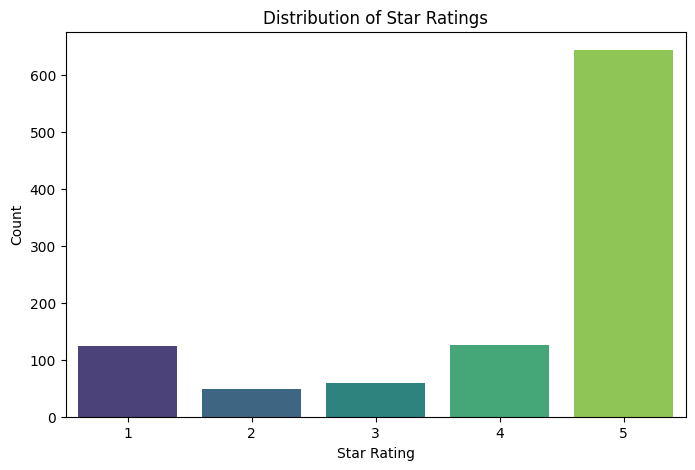

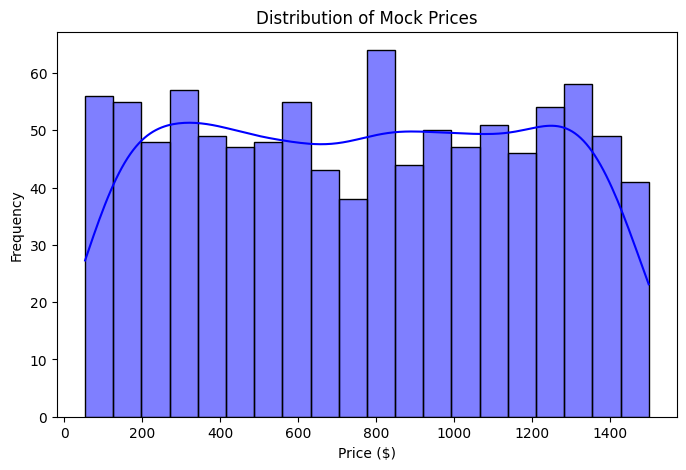

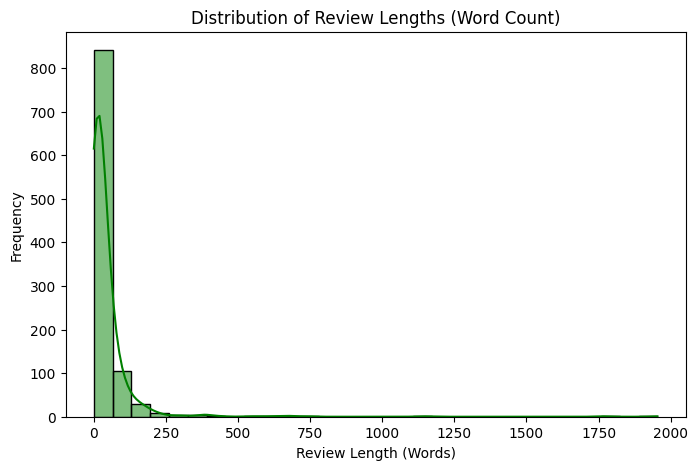

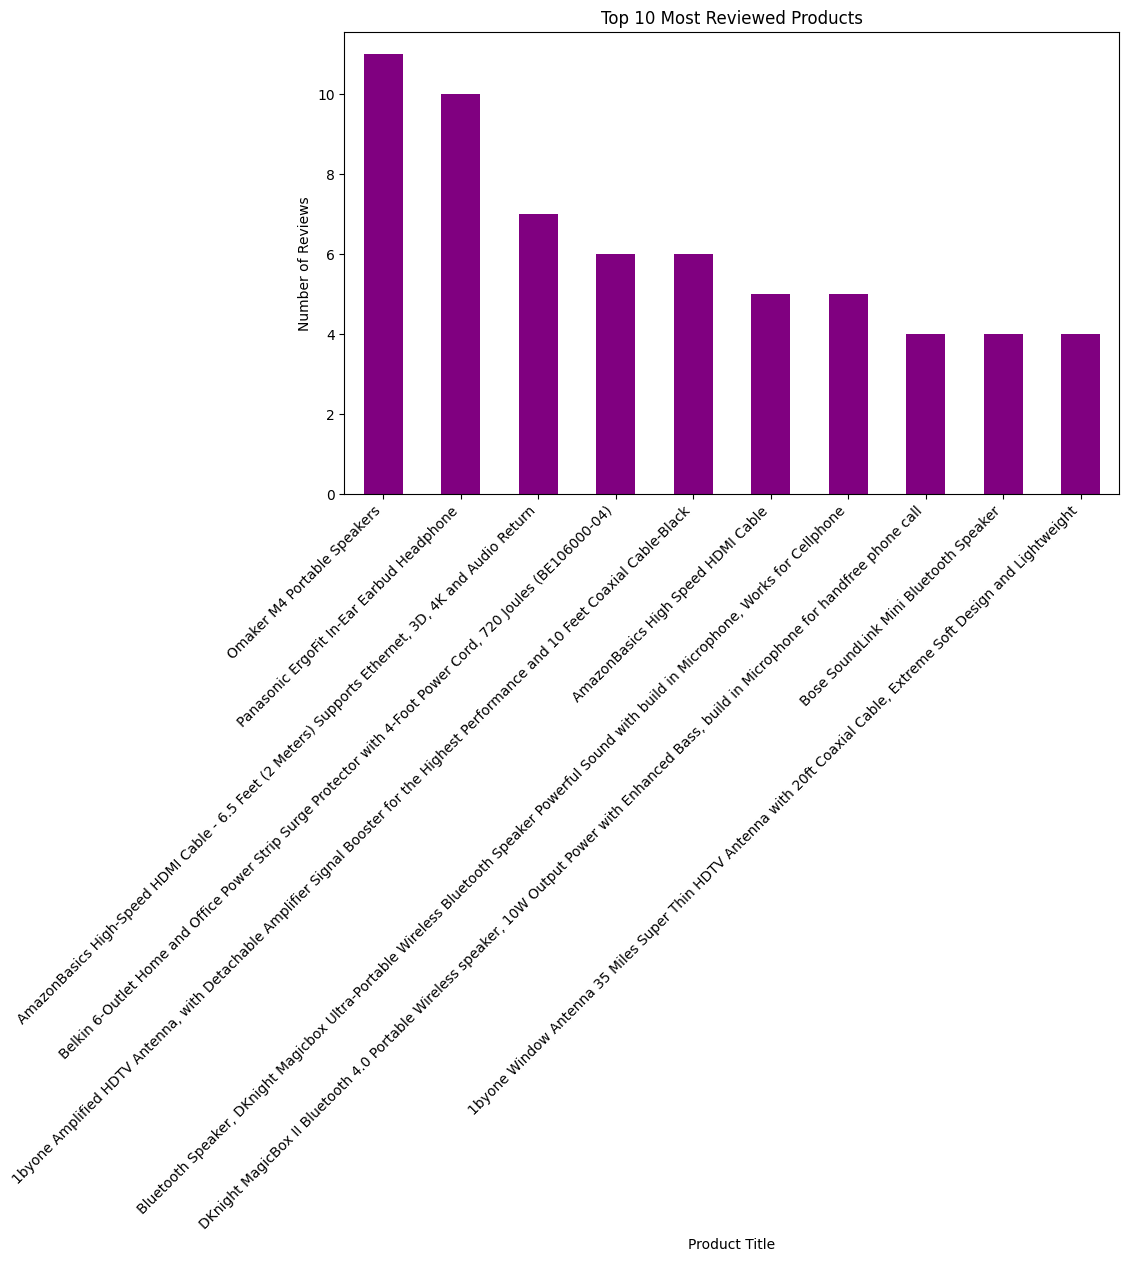


Missing Values:
product_id       0
product_title    0
star_rating      0
review_body      0
price            0
review_length    0
dtype: int64


In [3]:
# Basic info
print("Dataset Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 1. Distribution of Star Ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='star_rating', data=df, palette='viridis')
plt.title('Distribution of Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Count')
plt.show()

# 2. Distribution of Mock Prices
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=20, kde=True, color='blue')
plt.title('Distribution of Mock Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# 3. Review Length Analysis
df['review_length'] = df['review_body'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 5))
sns.histplot(df['review_length'], bins=30, kde=True, color='green')
plt.title('Distribution of Review Lengths (Word Count)')
plt.xlabel('Review Length (Words)')
plt.ylabel('Frequency')
plt.show()

# 4. Top 10 Most Reviewed Products
top_products = df['product_title'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='purple')
plt.title('Top 10 Most Reviewed Products')
plt.xlabel('Product Title')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.show()

# 5. Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

In [4]:
# Combine product title and review into a single text field
df['combined_text'] = df.apply(
    lambda row: f"Product: {row['product_title']} | Price: ${row['price']} | Rating: {row['star_rating']} | Review: {row['review_body']}", 
    axis=1
)

# Convert to LangChain Documents (Fixed: use row["combined_text"])
documents = [Document(page_content=row["combined_text"], metadata={"product_id": row["product_id"], "price": row["price"], "star_rating": row["star_rating"]}) 
             for _, row in df.iterrows()]

# Split text into smaller chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = text_splitter.split_documents(documents)

# Create embeddings and vector store
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vector_store = FAISS.from_documents(split_docs, embedding_model)

print("Vector store created with", len(split_docs), "documents.")


Vector store created with 1296 documents.


In [ ]:
# Set up a local LLM pipeline
llm_pipeline = pipeline("text-generation", model="distilgpt2", max_new_tokens=100)
llm = HuggingFacePipeline(pipeline=llm_pipeline)

# Define the RAG chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vector_store.as_retriever(search_kwargs={"k": 2}),  # Retrieve top 2 matches
    return_source_documents=True
)

In [ ]:
def get_recommendation(query):
    # Run the query through the RAG chain
    result = qa_chain({"query": query})
    retrieved_docs = result["source_documents"]
    generated_text = result["result"]
    
    # Debug: Print retrieved documents
    print("Retrieved Documents:")
    for i, doc in enumerate(retrieved_docs, 1):
        print(f"{i}. {doc.page_content[:100]}... | Price: ${doc.metadata['price']} | Rating: {doc.metadata['star_rating']}")
    
    # Filter by price and rating if specified
    max_price = None
    min_rating = 4  # Default to recommending 4+ star products
    if "under $" in query.lower():
        try:
            max_price = float(query.lower().split("under $")[1].split()[0])
            print(f"Filtering for max price: ${max_price}")
        except:
            pass
    if "rating" in query.lower():
        try:
            min_rating = float(query.lower().split("rating")[1].split()[0])
            print(f"Filtering for min rating: {min_rating}")
        except:
            pass
    
    # Extract relevant products
    recommended_products = []
    for doc in retrieved_docs:
        price = doc.metadata["price"]
        rating = doc.metadata["star_rating"]
        if (max_price is None or price <= max_price) and rating >= min_rating:
            recommended_products.append({
                "product_id": doc.metadata["product_id"],
                "text": doc.page_content
            })
    
    # Craft a response with more detail
    if recommended_products:
        response = "Here are my recommendations based on your request:\n"
        for i, prod in enumerate(recommended_products, 1):
            response += f"{i}. {prod['text']}\n"
        response += f"\nAdditional Info: {generated_text}"
    else:
        response = "Sorry, no products match your criteria.\n"
        response += "Possible reasons:\n"
        response += "- Retrieved items exceed the price limit or fall below the rating threshold.\n"
        response += "- The dataset subset may lack suitable laptops matching 'durable'.\n"
        response += "Check the retrieved documents above for details."
    
    return response

query = "Suggest a durable laptop under $1000 with rating 4 or higher"
response = get_recommendation(query)
print(response)

In [ ]:
while True:
    user_input = input("Ask me for a recommendation (or type 'exit' to quit): ")
    if user_input.lower() == "exit":
        break
    print(get_recommendation(user_input))
    print("-" * 50)